## Deep Neural Network for synthetic time series data

In [103]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### Utilities

In [104]:
def plot_series(time, series, format="-", start=0, end=None):
    """
    Visualizes time series data

    Args:
      time (array of int) - contains the time steps
      series (array of int) - contains the measurements for each time step
      format - line style when plotting the graph
      label - tag for the line
      start - first time step to plot
      end - last time step to plot
    """

    # Setup dimensions of the graph figure
    plt.figure(figsize=(10, 6))
    
    if type(series) is tuple:

      for series_num in series:
        # Plot the time series data
        plt.plot(time[start:end], series_num[start:end], format)

    else:
      # Plot the time series data
      plt.plot(time[start:end], series[start:end], format)

    # Label the x-axis
    plt.xlabel("Time")

    # Label the y-axis
    plt.ylabel("Value")

    # Overlay a grid on the graph
    plt.grid(True)

    # Draw the graph on screen
    plt.show()


def trend(time, slope=0):
    """
    Generates synthetic data that follows a straight line given a slope value.

    Args:
      time (array of int) - contains the time steps
      slope (float) - determines the direction and steepness of the line

    Returns:
      series (array of float) - measurements that follow a straight line
    """

    # Compute the linear series given the slope
    series = slope * time

    return series


def seasonal_pattern(season_time):
    """
    Just an arbitrary pattern, you can change it if you wish
    
    Args:
      season_time (array of float) - contains the measurements per time step

    Returns:
      data_pattern (array of float) -  contains revised measurement values according 
                                  to the defined pattern
    """

    # Generate the values using an arbitrary pattern
    data_pattern = np.where(season_time < 0.4,
                    np.cos(season_time * 2 * np.pi),
                    1 / np.exp(3 * season_time))
    
    return data_pattern


def seasonality(time, period, amplitude=1, phase=0):
    """
    Repeats the same pattern at each period

    Args:
      time (array of int) - contains the time steps
      period (int) - number of time steps before the pattern repeats
      amplitude (int) - peak measured value in a period
      phase (int) - number of time steps to shift the measured values

    Returns:
      data_pattern (array of float) - seasonal data scaled by the defined amplitude
    """
    
    # Define the measured values per period
    season_time = ((time + phase) % period) / period

    # Generates the seasonal data scaled by the defined amplitude
    data_pattern = amplitude * seasonal_pattern(season_time)

    return data_pattern


def noise(time, noise_level=1, seed=None):
    """Generates a normally distributed noisy signal

    Args:
      time (array of int) - contains the time steps
      noise_level (float) - scaling factor for the generated signal
      seed (int) - number generator seed for repeatability

    Returns:
      noise (array of float) - the noisy signal
    """

    # Initialize the random number generator
    rnd = np.random.RandomState(seed)

    # Generate a random number for each time step and scale by the noise level
    noise = rnd.randn(len(time)) * noise_level
    
    return noise

### Generate synthetic data

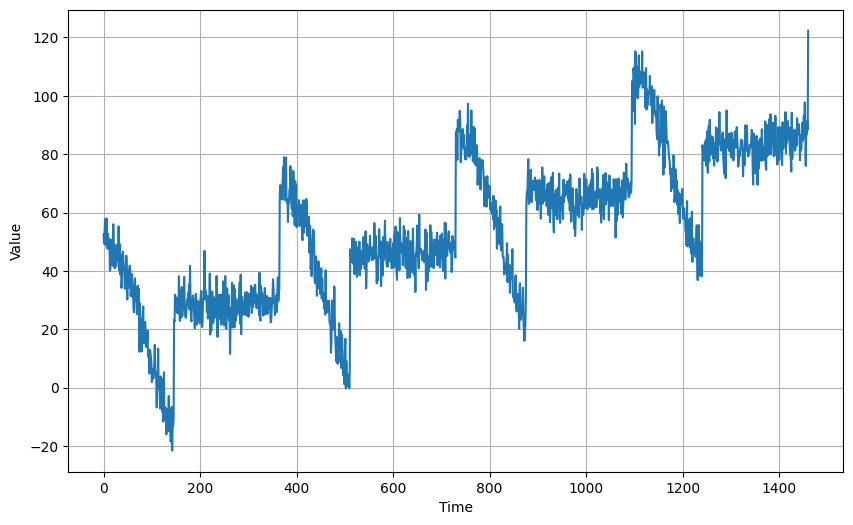

In [105]:
# Parameters
time = np.arange(4 * 365 + 1, dtype="float32")
baseline = 10
amplitude = 40
slope = 0.05
noise_level = 5

# Create the series
series = baseline + trend(time, slope) + seasonality(time, period=365, amplitude=amplitude)

# Update with noise
series += noise(time, noise_level, seed=42)

# Plot the results
plot_series(time, series)

### Split the dataset

In [106]:
split_time = 1000

# Training set 0 -> split_time-1
time_train = time[:split_time]
x_train = series[:split_time]

# Validation set split_time -> end
time_valid = time[split_time:]
x_valid = series[split_time:]

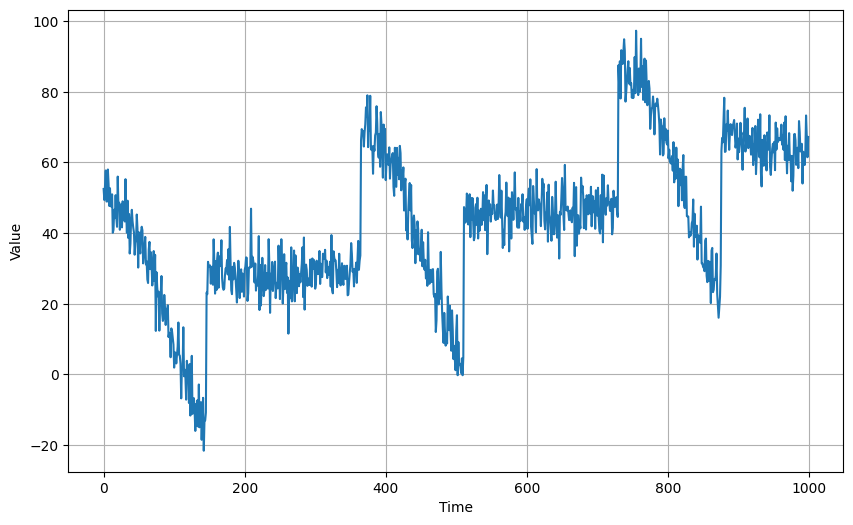

In [107]:
plot_series(time_train, x_train)

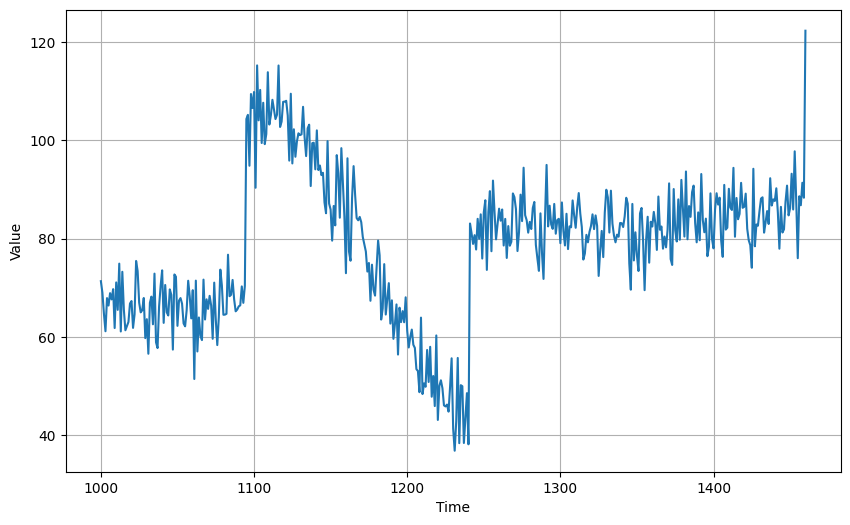

In [108]:
plot_series(time_valid, x_valid)

### Prepare features & labels

<br>

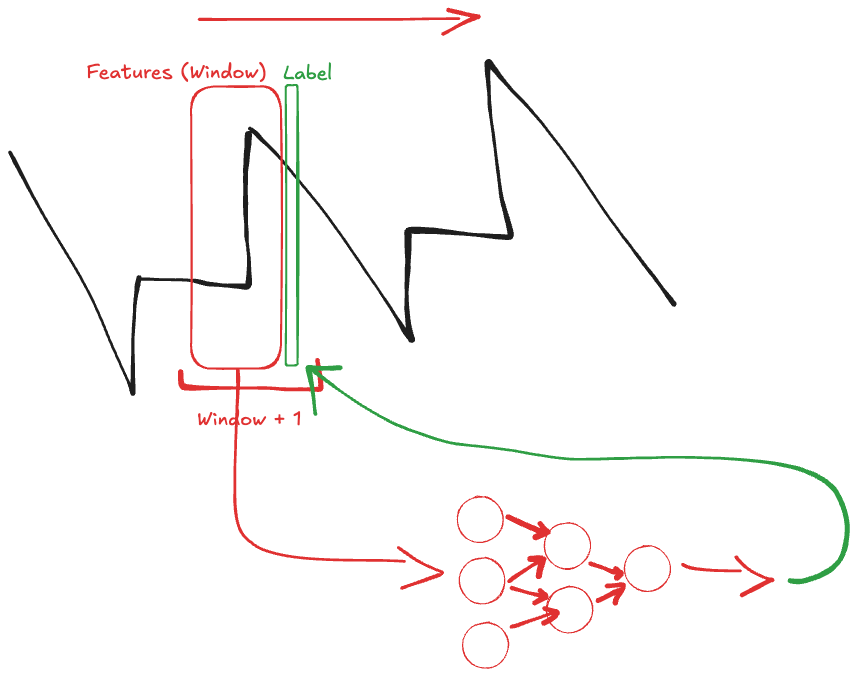

In [109]:
window_size = 20
batch_size = 30
shuffle_buffer_size = 1000

In [110]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)
    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))
    # Create tuples with features and labels 
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))
    # Shuffle the windows
    dataset = dataset.shuffle(shuffle_buffer)
    # Create batches of windows
    dataset = dataset.batch(batch_size)
    # Optimize the dataset for training
    dataset = dataset.cache().prefetch(1)
    
    return dataset

In [111]:
dataset = windowed_dataset(series, window_size, batch_size, shuffle_buffer_size)

In [112]:
for windows in dataset.take(1):
    print(f'data type: {type(windows)}')
    print(f'number of elements in the tuple: {len(windows)}')
    print(f'shape of first element: {windows[0].shape}')
    print(f'shape of second element: {windows[1].shape}')
    print(windows[1])

data type: <class 'tuple'>
number of elements in the tuple: 2
shape of first element: (30, 20)
shape of second element: (30,)
tf.Tensor(
[31.5976   51.99936  20.18714  57.16999  31.098982 88.96491  64.142975
 35.775608 65.58317  25.05581  54.642056 64.18593  66.44626  13.98788
 28.563086 23.864828 50.697735 28.487524 32.771015 61.960625 25.906002
 52.675735 31.45096  69.481316 19.817165 49.91921  79.90539  55.509987
 40.649796 40.079105], shape=(30,), dtype=float32)


2025-09-17 16:17:07.814631: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Build and compile - Deep neural network model

#### Part 1 - Baseline model without optimized learning rate

In [113]:
input_layer = tf.keras.Input(shape=(window_size,))
x = tf.keras.layers.Dense(10, activation='relu')(input_layer)
x = tf.keras.layers.Dense(10, activation='relu')(x)
output_layer = tf.keras.layers.Dense(1)(x)

model_baseline = tf.keras.Model(input_layer, output_layer)
model_baseline.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331 (1.29 KB)

 Trainable params: 331 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
model_baseline.compile(loss="mse", optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))

In [115]:
model_baseline.fit(dataset, epochs=100)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5306.3926
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 141.3296
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 135.6427
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 95.9865
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 86.6053
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 79.4367
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 75.0959
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70.9335
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 68.5376
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 66.3263
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 64.9317
Epoch 12/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 63.6613
Epoch 13/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 62.6736
Epoch 14/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 61.7388
Epoch 15/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step -

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 48.6356
Epoch 82/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 48.7326
Epoch 83/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 48.5533
Epoch 84/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 48.4546
Epoch 85/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.3484
Epoch 86/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.4432
Epoch 87/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 48.2863
Epoch 88/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.1939
Epoch 89/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 48.0946
Epoch 90/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 48.0237
Epoch 91/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 47.9647
Epoch 92/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 47.9017
Epoch 93/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 47.9980
Epoch 94/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 47.8583
Epoch 95/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4

### Model prediction

In [116]:
forecast = []

for time in range(len(series)-window_size):
    forecast.append(model_baseline.predict(series[time:time+window_size][np.newaxis], verbose=0))
    
forecast = forecast[split_time - window_size:]
# Compare number of elements in the predictions and the validation set
print(f'length of the forecast list: {len(forecast)}')
print(f'shape of the validation set: {x_valid.shape}')

length of the forecast list: 461
shape of the validation set: (461,)


shape after converting to numpy array: (461, 1, 1)
shape after squeezing: (461,)


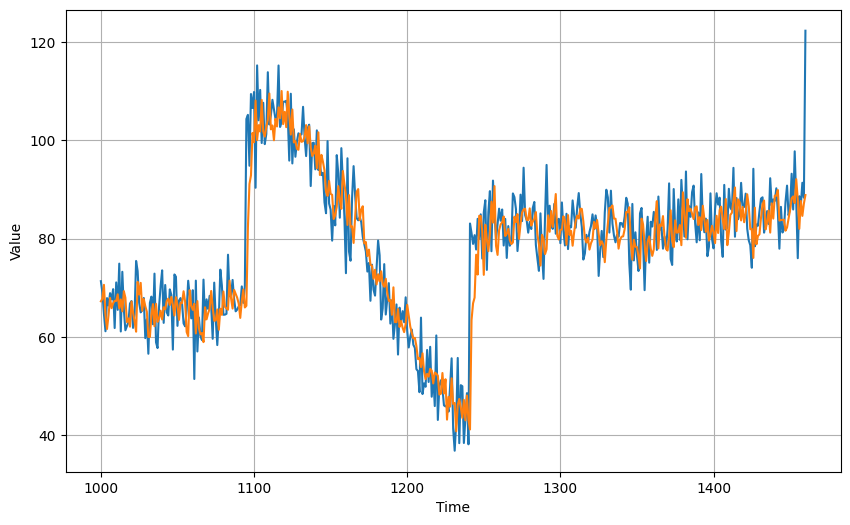

In [117]:
# Preview shapes after using the conversion and squeeze methods
print(f'shape after converting to numpy array: {np.array(forecast).shape}')
print(f'shape after squeezing: {np.array(forecast).squeeze().shape}')

# Convert to a numpy array and drop single dimensional axes
results = np.array(forecast).squeeze()

# Overlay the results with the validation set
plot_series(time_valid, (x_valid, results))

In [118]:
# Compute the metrics
print(tf.keras.metrics.mse(x_valid, results).numpy())
print(tf.keras.metrics.mae(x_valid, results).numpy())

46.737778
5.12738


### Fine-tuning the learning rate

    1. Schedule a learning rate scheduler and train the model (which modifies the lr on every epoch)
    2. Plot the lr v/s loss graph for the epochs and pick the lr which corresponds to the lowest loss
    3. 

In [119]:
input_layer = tf.keras.Input(shape=(window_size,))
x = tf.keras.layers.Dense(10, activation='relu')(input_layer)
x = tf.keras.layers.Dense(10, activation='relu')(x)
output_layer = tf.keras.layers.Dense(1)(x)

model_tuned = tf.keras.Model(input_layer, output_layer)
model_tuned.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331 (1.29 KB)

 Trainable params: 331 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

Next, you will declare a [learning rate scheduler](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/LearningRateScheduler) callback. This will allow you to dynamically set the learning rate based on the epoch number during training. As shown below, you will pass a lambda function to declare the value of the learning rate. It will start at `1e-8` at epoch 0 and is scaled by `10**(epoch / 20)` as the training goes on.

<br><br>
At the beginning of every epoch, this callback gets the updated learning rate value from schedule function provided at __init__, with the current epoch and current learning rate, and applies the updated learning rate on the optimizer.



In [120]:
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-8 * 10**(epoch / 20)
)

In [121]:
model_tuned.compile(loss='mse', optimizer=tf.keras.optimizers.SGD(momentum=0.9))

In [122]:
history = model_tuned.fit(dataset, epochs=100, callbacks=[lr_schedule])

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 698.4760 - learning_rate: 1.0000e-08
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 449.9165 - learning_rate: 1.1220e-08
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 268.7828 - learning_rate: 1.2589e-08
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 168.6916 - learning_rate: 1.4125e-08
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 124.1931 - learning_rate: 1.5849e-08
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 108.6922 - learning_rate: 1.7783e-08
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 104.4649 - learning_rate: 1.9953e-08
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 103.4269 - learning_rate: 2.2387e-08
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 103.0115 - learning_rate: 2.5119e-08
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 102.5940 - learning_rate: 2.8184e-08
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━

Epoch 64/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 63.8262 - learning_rate: 1.4125e-05
Epoch 65/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 80.2143 - learning_rate: 1.5849e-05
Epoch 66/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 61.0774 - learning_rate: 1.7783e-05
Epoch 67/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 53.6817 - learning_rate: 1.9953e-05
Epoch 68/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 53.7946 - learning_rate: 2.2387e-05
Epoch 69/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 54.1536 - learning_rate: 2.5119e-05
Epoch 70/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 53.2823 - learning_rate: 2.8184e-05
Epoch 71/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 52.8207 - learning_rate: 3.1623e-05
Epoch 72/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 51.9362 - learning_rate: 3.5481e-05
Epoch 73/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 51.7439 - learning_rate: 3.9811e-05
Epoch 74/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 

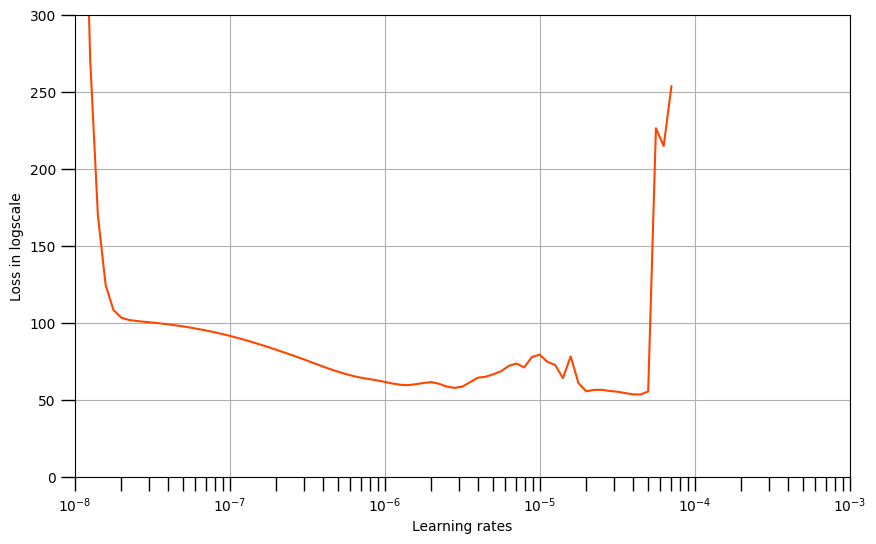

In [123]:
lrs = 1e-8 * (10**(np.arange(100)/20))
plt.figure(figsize=(10,6))
plt.grid(True)
plt.semilogx(lrs, history.history['loss'], color="orangered")
plt.xlabel("Learning rates")
plt.ylabel("Loss in logscale")
plt.tick_params('both', length=10, width=1, which='both')
plt.axis([1e-8, 1e-3, 0, 300])
plt.show()

### Final model with revised learning rate

In [134]:
epoch_min_loss = np.argmin(history.history['loss'])
lr_final = 1e-8 * 10**(epoch_min_loss / 20)
# Build the model
model_final = tf.keras.models.Sequential([
    tf.keras.Input(shape=(window_size,)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.SGD(learning_rate=3e-6, momentum=0.9)
model_final.compile(loss="mse", optimizer=optimizer)
history = model_final.fit(dataset, epochs=100)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 131.6705
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 114.5832
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 78.8288
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 74.5394
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 69.0333
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 65.9028
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 63.7297
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 60.0472
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 58.3086
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 58.5316
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 55.9773
Epoch 12/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 56.3833
Epoch 13/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 54.6800
Epoch 14/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 55.4215
Epoch 15/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - l

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 45.6324
Epoch 82/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 45.5776
Epoch 83/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 45.4047
Epoch 84/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.5046
Epoch 85/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 45.3479
Epoch 86/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.4964
Epoch 87/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.3875
Epoch 88/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 45.4488
Epoch 89/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 45.2645
Epoch 90/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.3794
Epoch 91/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.3678
Epoch 92/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.3644
Epoch 93/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 45.2290
Epoch 94/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 45.2941
Epoch 95/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss:

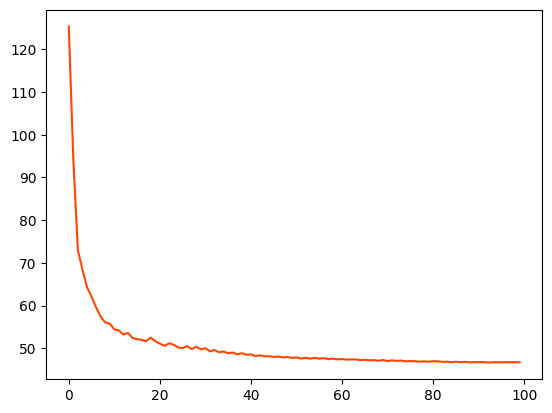

In [137]:
# Plot the loss
loss = history.history['loss']
epochs = range(len(loss))
plt.plot(epochs, loss, label='Training Loss', color="orangered")
plt.show()

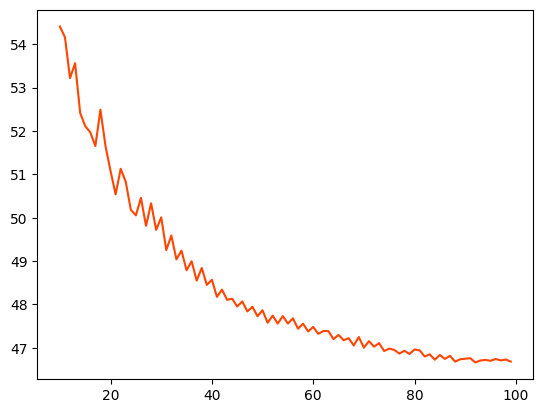

In [138]:
loss = history.history['loss']
epochs = range(10, len(loss))
plot_loss = loss[10:]
plt.plot(epochs, plot_loss, label="Trainin loss", color="orangered")
plt.show()

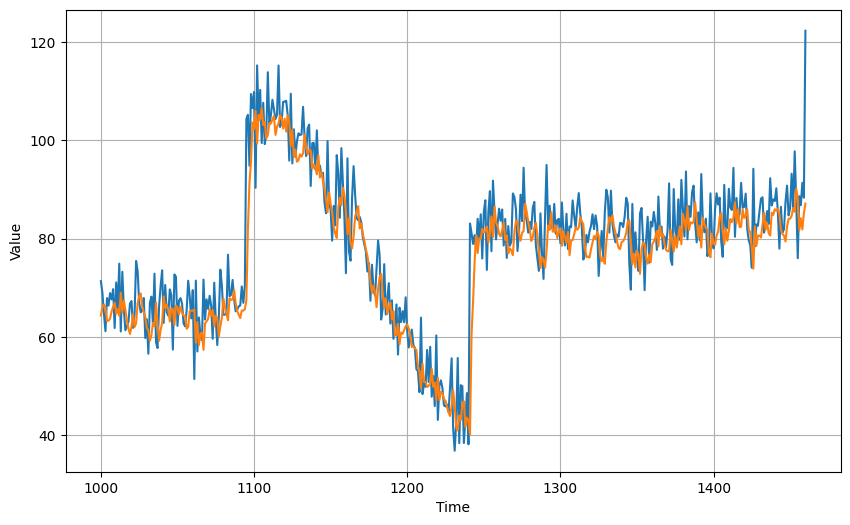

In [139]:
# Initialize a list
forecast = []

# Reduce the original series
forecast_series = series[split_time - window_size:]

# Use the model to predict data points per window size
for time in range(len(forecast_series) - window_size):
  forecast.append(model_final.predict(forecast_series[time:time + window_size][np.newaxis], verbose=0))

# Convert to a numpy array and drop single dimensional axes
results = np.array(forecast).squeeze()

# Plot the results
plot_series(time_valid, (x_valid, results))

In [140]:
print(tf.keras.metrics.mse(x_valid, results).numpy())
print(tf.keras.metrics.mae(x_valid, results).numpy())

48.859425
5.1370893
